# Лабораторная работа 3
## (24 балла)

№1 (3 балла)
1. Создайте объект Series, значениями которого являются целые числа от 1 до 5, а
индексами символы 'a', 'b', 'c', 'd', 'e'.
1. С помощью обращения по явному индексу получите значение 4.
2. С помощью обращения по неявному индексу получите значение 2.
3. Добавьте в серию новый элемент.
4. Используя операцию среза, получите значения 3, 4, 5.
5. Создайте объект DataFrame из списка [[1, 2], [5, 3], [3.7, 4.8]] с именами столбцов
col1 и col2.
6. Используя операцию индексации, получите элемент 3.7.
7. Измените элемент 3 на 9.
8. Используя операцию среза, получите строки с индексами 1 и 2.
9. Добавьте столбец col3, значения которого – результат поэлементного
перемножения col1 и col2.

In [45]:
import pandas as pd

In [46]:
series = pd.Series([1,2,3,4,5], index=['a', 'b', 'c', 'd', 'e'])
print(series)

a    1
b    2
c    3
d    4
e    5
dtype: int64


In [47]:
value = series['d']
print(value)

4


In [48]:
value = series.iloc[1]
print(value)

2


In [49]:
series['f'] = 6
print(series)

a    1
b    2
c    3
d    4
e    5
f    6
dtype: int64


In [50]:
slice_series = series['c':'e']
print(slice_series)   

c    3
d    4
e    5
dtype: int64


In [51]:
data_frame = pd.DataFrame([[1, 2], [5, 3], [3.7, 4.8]], columns=['col1', 'col2'])
print(data_frame)

   col1  col2
0   1.0   2.0
1   5.0   3.0
2   3.7   4.8


In [52]:
element = data_frame.loc[2, 'col1']
print(element)

3.7


In [53]:
copy_data_frame = data_frame.copy()
copy_data_frame.loc[1, 'col2'] = 9
print(copy_data_frame)


   col1  col2
0   1.0   2.0
1   5.0   9.0
2   3.7   4.8


In [54]:
slice_rows = data_frame.loc[1:2]
print(slice_rows)

   col1  col2
1   5.0   3.0
2   3.7   4.8


In [55]:
copy_data_frame = data_frame.copy()
copy_data_frame['col3'] = copy_data_frame['col1'] * copy_data_frame['col2']
print(copy_data_frame)

   col1  col2   col3
0   1.0   2.0   2.00
1   5.0   3.0  15.00
2   3.7   4.8  17.76


№2 (4 балла) <br/>
Дан список списков data.
```
data = [["Вжик", "Zipper the Fly", "fly", "0.7"], 
["Гайка", "Gadget Hackwrench", "mouse", None],
["Дейл", "Dale", "chipmunk", "1"],
["Рокфор", "Monterey Jack", "mouse", "0.8"],
["Чип", "Chip", "chipmunk", "0.2"]]
```
На первом месте указывается имя героя на русском (ru_name), затем имя на английском
(en_name), вид героя (class) и индекс веселости, который измеряется в «Дейлах» (cheer).
1. На основе этого списка создайте датафрейм df так, чтобы каждому показателю
(ru_name, en_name, class, cheer) соответствовал один столбец датафрейма.
Проверьте, что последний столбец является числовым. Если нет, приведите его к
типу float.
2. Выведите число строк датафрейма df.
3. Выведите число заполненных (не NaN) ячеек в последнем столбце.
4. Выведите значение в ячейке, которая находится на пересечении третьей строки и
второго столбца.
5. Сохраните в переменную df1 строки датафрейма df со второй по четвертую
включительно и столбцы с первого по третий включительно. Продемонстрируйте
содержимое df1.
6. Присвойте столбцам датафрейма df следующие названия: ru_name, en_name, class,
cheer.
7. Добавьте в датафрейм df столбец logcheer, который содержит логарифмированные
значения cheer (если в cheer встречается NaN, то и в logcheer тоже).
8. Сохраните массив уникальных значений столбца class в переменную x, а
соответствующие им частоты (сколько раз значение встречается в столбце) — в
переменную y. Используя полученные x и y, постройте столбиковую диаграмму,
barplot, для class. Добавьте заголовок и подписи к осям.

In [56]:
import numpy as np
import matplotlib.pyplot as plt

In [57]:
data = [["Вжик", "Zipper the Fly", "fly", "0.7"],
["Гайка", "Gadget Hackwrench", "mouse", None],
["Дейл", "Dale", "chipmunk", "1"],
["Рокфор", "Monterey Jack", "mouse", "0.8"],
["Чип", "Chip", "chipmunk", "0.2"]]


In [58]:
data_frame = pd.DataFrame(data, columns=["ru_name", "en_name", "class", "cheer"])
data_frame["cheer"] = pd.to_numeric(data_frame["cheer"], errors="coerce")
print(data_frame)

  ru_name            en_name     class  cheer
0    Вжик     Zipper the Fly       fly    0.7
1   Гайка  Gadget Hackwrench     mouse    NaN
2    Дейл               Dale  chipmunk    1.0
3  Рокфор      Monterey Jack     mouse    0.8
4     Чип               Chip  chipmunk    0.2


In [59]:
count_rows_df = data_frame.shape[0]
print(count_rows_df)

5


In [60]:
count_non_nan = data_frame["cheer"].count()
print(count_non_nan)

4


In [61]:
cell_value = data_frame.iat[2,1]
print(cell_value)

Dale


In [62]:
df1 = data_frame.iloc[1:4, 0:3]
print(df1)

  ru_name            en_name     class
1   Гайка  Gadget Hackwrench     mouse
2    Дейл               Dale  chipmunk
3  Рокфор      Monterey Jack     mouse


In [63]:
#Это уже сделано, поэтому скип. Создается при обращении к DataFrame

In [64]:
copy_data_frame = data_frame.copy()
copy_data_frame["logcheer"] = np.log(copy_data_frame["cheer"])
print(copy_data_frame)

  ru_name            en_name     class  cheer  logcheer
0    Вжик     Zipper the Fly       fly    0.7 -0.356675
1   Гайка  Gadget Hackwrench     mouse    NaN       NaN
2    Дейл               Dale  chipmunk    1.0  0.000000
3  Рокфор      Monterey Jack     mouse    0.8 -0.223144
4     Чип               Chip  chipmunk    0.2 -1.609438


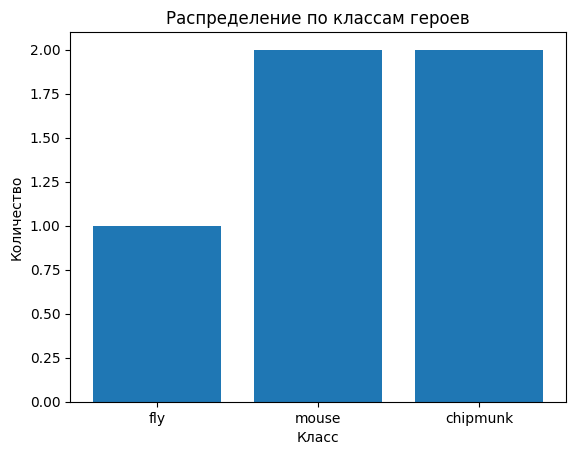

In [65]:
x = data_frame['class'].unique()
y = data_frame['class'].value_counts().loc[x]

plt.bar(x, y)
plt.title('Распределение по классам героев')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.show()